# **Financial Market Risk & Factor Analysis Using Statistical Distributions and PCA**

Dataset:
S&P 500 Stock Prices Dataset

This dataset contains:

* Daily stock prices
* Multiple companies
* Time series financial data

Typical columns:

```
Date
Symbol
Open
High
Low
Close
Volume
```

From these we will compute:

* Returns (random variables)
* Distribution properties
* Risk statistics
* Covariance structure
* PCA factors
* Feature stability
* Noise filtering

---

# 🧠 Problem Statement

Financial markets exhibit complex statistical behavior.

Classical statistics often assume:

* Normal distributions
* Independent observations
* Stable variance

However real financial data frequently violates these assumptions.

The objective of this project is to:

1. Model stock returns as **random variables**
2. Study **distribution characteristics**
3. Compute **mean, variance, skewness, kurtosis**
4. Estimate **confidence intervals**
5. Conduct **hypothesis testing**
6. Understand **why statistical assumptions fail in financial markets**
7. Represent financial data using **vectors and matrices**
8. Compute **covariance matrices**
9. Extract latent market factors using **PCA**
10. Evaluate **feature stability across time**
11. Remove **noisy features**

---

# 1️⃣ Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as stats
from scipy.stats import ttest_1samp

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---

# 2️⃣ Load Dataset

In [ ]:
path = '/content/drive/MyDrive/Data/S&P_10/'

Tickers = ['AAPL', 'AMD', 'AMZN', 'CSCO', 'GOOG', 'IBM', 'MSFT', 'NFLX', 'SBUX', 'TSLA']

In [ ]:
price_col = ''

In [ ]:
all_tickers = []

In [ ]:
for t in Tickers:
  file_path = f'{path}{t}.csv'
  globals()[f'df_{t}'] = pd.read_csv(file_path)
  all_tickers.append(globals()[f'df_{t}'])

In [ ]:
df_TSLA.head()

,Ticker,Date,Open,High,Low,Close,Adj Close,Volume
0,TSLA,2010-06-29,1.266667,1.666667,1.169333,1.592667,1.592667,281494500
1,TSLA,2010-06-30,1.719333,2.028000,1.553333,1.588667,1.588667,257806500
2,TSLA,2010-07-01,1.666667,1.728000,1.351333,1.464000,1.464000,123282000
3,TSLA,2010-07-02,1.533333,1.540000,1.247333,1.280000,1.280000,77097000
4,TSLA,2010-07-06,1.333333,1.333333,1.055333,1.074000,1.074000,103003500


The dataset contains Tesla stock price data which began in June 2010. The first trading day show significanant trading activity with strong upward price movement.

In [ ]:
df = pd.concat(all_tickers, axis=0, ignore_index=True)

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

In [ ]:
df = df.sort_values(by=['Date'],ascending=False)

In [ ]:
df.head(10)

,Ticker,Date,Open,High,Low,Close,Adj Close,Volume
3296,TSLA,2023-08-03,252.039993,258.750000,252.000000,257.790009,257.790009,70768230
7832,SBUX,2023-08-03,101.970001,102.900002,101.445000,102.369003,102.369003,2870035
4771,GOOG,2023-08-03,128.369995,129.770004,127.779999,129.341202,129.341202,9509514
15502,IBM,2023-08-03,143.779999,145.119995,143.311600,144.570007,144.570007,1709503
6597,AMZN,2023-08-03,127.480003,129.839996,126.410004,129.210007,129.210007,38382291
9423,MSFT,2023-08-03,326.000000,329.880005,325.950012,327.829712,327.829712,10999690
8428,CSCO,2023-08-03,52.490002,53.205002,52.240002,53.099998,53.099998,7191333
5335,NFLX,2023-08-03,427.799988,441.829987,427.190002,438.475708,438.475708,3649079
10749,AAPL,2023-08-03,191.570007,192.369995,190.839996,191.315002,191.315002,27011819
10937,AMD,2023-08-03,108.949997,114.959999,109.000000,114.050003,114.050003,67464695


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 82880 entries, 3296 to 0
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Ticker     82880 non-null  object        
 1   Date       82880 non-null  datetime64[ns]
 2   Open       82880 non-null  float64       
 3   High       82880 non-null  float64       
 4   Low        82880 non-null  float64       
 5   Close      82880 non-null  float64       
 6   Adj Close  82880 non-null  float64       
 7   Volume     82880 non-null  int64         
dtypes: datetime64[ns](1), float64(5), int64(1), object(1)
memory usage: 5.7+ MB


Dataset contains 82,880 rolls and 8 columns. The dataset contains no missing values. Prices are stored as numerical values, dates are correctly formatted as datetime making the dataset suitable for time-series financial analysis.

In [ ]:
df.describe()

,Date,Open,High,Low,Close,Adj Close,Volume
count,82880,82880.000000,82880.000000,82880.000000,82880.000000,82880.000000,8.288000e+04
mean,2004-05-12 19:16:51.891891712,42.458069,43.039970,41.947135,42.505615,36.843065,8.187889e+07
min,1962-01-02 00:00:00,0.000000,0.049665,0.049107,0.049107,0.038102,0.000000e+00
25%,1995-09-05 00:00:00,4.555536,4.750000,4.550502,4.656145,3.484074,7.171612e+06
50%,2006-09-29 00:00:00,16.566881,16.776727,16.370001,16.573341,12.706884,2.778840e+07
75%,2015-05-11 06:00:00,45.582501,46.094307,45.060001,45.619999,39.767752,8.245372e+07
max,2023-08-03 00:00:00,692.349976,700.989990,686.090027,691.690002,691.690002,7.421641e+09
std,NaN,69.879453,70.810521,68.862701,69.859313,67.576211,1.697791e+08


The dataset contains 82,880 observations covering stock prices from 1962 to 2023. The average closing price is about $42.50, while

the median price is $16.57. This indicates that some stocks have much higher prices than others. The large standard deviation shows that stock prices vary widely across companies. Trading volume also varies significantly, indicating periods of high market activity.

Example structure:

| Date       | Symbol | Close |
| ---------- | ------ | ----- |
| 2020-01-01 | AAPL   | 300   |
| 2020-01-01 | MSFT   | 160   |

---

# 3️⃣ Data Preparation

Convert to pivot table.

Rows = Date
Columns = Stocks

In [ ]:
price = df.pivot_table(index='Date', columns='Ticker', values='Close')
prices = price.sort_index()

prices.head()

Ticker,AAPL,AMD,AMZN,CSCO,GOOG,IBM,MSFT,NFLX,SBUX,TSLA
Date,,,,,,,,,,
1962-01-02,NaN,NaN,NaN,NaN,NaN,7.291268,NaN,NaN,NaN,NaN
1962-01-03,NaN,NaN,NaN,NaN,NaN,7.355003,NaN,NaN,NaN,NaN
1962-01-04,NaN,NaN,NaN,NaN,NaN,7.281708,NaN,NaN,NaN,NaN
1962-01-05,NaN,NaN,NaN,NaN,NaN,7.138305,NaN,NaN,NaN,NaN
1962-01-08,NaN,NaN,NaN,NaN,NaN,7.004461,NaN,NaN,NaN,NaN


In [ ]:
prices.isnull().sum()

,0
Ticker,
AAPL,4753
AMD,4565
AMZN,8905
CSCO,7074
GOOG,10731
IBM,0
MSFT,6079
NFLX,10167
SBUX,7670


The missing value analysis shows that some stocks have missing prices because they were not publicly traded during earlier years in the dataset. Newer companies like Tesla and Google have more missing observations, while older companies like IBM have complete historical data.

In [ ]:
prices.dropna(inplace=True)

In [ ]:
prices.shape

(3297, 10)

---

# 4️⃣ Random Variables

A **random variable** is a variable whose value depends on the outcome of a random event.

In finance:

**Daily stock return = random variable**

$$
R_t = \frac{P_t - P_{t-1}}{P_{t-1}}
$$
---

### Compute Returns

In [ ]:
returns = prices.pct_change().dropna()

In [ ]:
returns.head()

Ticker,AAPL,AMD,AMZN,CSCO,GOOG,IBM,MSFT,NFLX,SBUX,TSLA
Date,,,,,,,,,,
2010-06-30,-0.018113,-0.021390,0.005985,-0.014339,-0.020495,-0.012871,-0.012870,-0.034908,-0.028389,-0.002511
2010-07-01,-0.012126,0.009563,0.015559,-0.002346,-0.012271,-0.007370,0.006519,0.009296,0.014815,-0.078473
2010-07-02,-0.006198,-0.029770,-0.016402,-0.006115,-0.006690,-0.005793,0.004750,-0.023527,-0.012571,-0.125683
2010-07-06,0.006844,-0.018131,0.008430,0.009939,-0.001100,0.013130,0.023636,0.001774,-0.030390,-0.160937
2010-07-07,0.040381,0.049716,0.030620,0.053421,0.032403,0.028673,0.020151,0.104596,0.033460,-0.019243


Each column is now a **random variable representing daily returns**.

---

# 5️⃣ Normal vs Heavy-Tailed Distributions

Finance theory often assumes:

Returns follow a **Normal distribution**.

However empirical evidence shows:

Returns are **heavy-tailed**.

Meaning:

* Extreme events occur more frequently.

---

### Visualizing Distribution

In [ ]:
sns.histplot(returns['GOOG'],bins=50, kde=True)
plt.title("Distribution of Google return")
plt.xlabel("Daily Returns")
plt.ylabel("Number of days")
plt.show()

NameError: name 'sns' is not defined

The distribution of Google returns is centered around zero, indicating that most daily price changes are relatively small.

---

### Compare with Normal Distribution


In [ ]:
mu = returns['GOOG'].mean()
sigma = returns['GOOG'].std()

x = np.linspace(-0.1, 0.1,100)

norm_pdf = stats.norm.pdf(x, mu, sigma)



A normal distribution was fitted using the mean and standard deviation of Google returns. This allows comparison between the theoretical normal model and the actual return distribution. The comparison helps identify whether market returns follow a normal distribution or exhibit heavier tails.

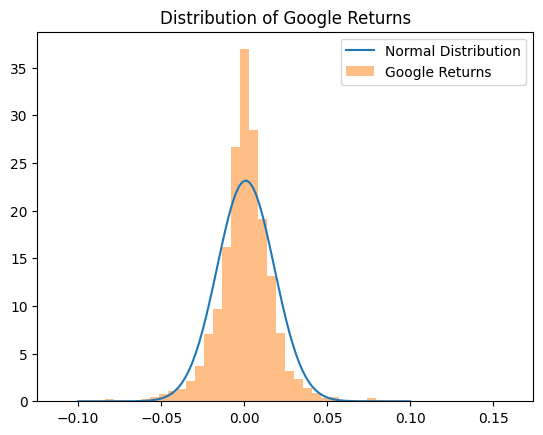

In [ ]:
plt.plot(x, norm_pdf, label='Normal Distribution')
plt.hist(returns['GOOG'], bins=50, density=True, alpha=0.5, label='Google Returns')
plt.title('Distribution of Google Returns')
plt.legend()
plt.show()

The histogram shows the distribution of Google daily returns and compares it with a theoretical normal distribution. Most returns are close to zero, but the histogram shows heavier tails than the normal curve. This suggests that extreme price movements occur more often than predicted by the normal distribution.

Observation:

Heavy tails compared to normal.

---

# 6️⃣ Descriptive Statistics

Compute statistical properties.

---

## Mean

$$
\mu = E[X]
$$

Average return.

---

## Variance

$$
\sigma^2 = E[(X-\mu)^2]
$$

Measures volatility.

---

## Skewness

Measures asymmetry.

```
Skew > 0 → Right tail
Skew < 0 → Left tail
```

Markets often show **negative skewness**.

Meaning large negative crashes.

---

## Kurtosis

Measures tail heaviness.

```
Normal distribution kurtosis = 3
```

Financial returns often have:

```
Kurtosis > 3
```

Heavy tails.

---

In [ ]:
stats_summary = pd.DataFrame(
    {
        'Mean' : returns.mean(),
        'Variance' : returns.var(),
        'Skewness' : returns.skew(),
        'Kurtosis' : returns.kurt()
    }
)

In [ ]:
stats_summary.head()

,Mean,Variance,Skewness,Kurtosis
Ticker,,,,
AAPL,0.001082,0.000318,-0.061372,5.321211
AMD,0.001457,0.001282,1.023618,16.912698
AMZN,0.001177,0.000432,0.293330,6.636643
CSCO,0.000413,0.000279,-0.419299,15.709450
GOOG,0.000887,0.000297,0.492311,8.565850


The statistical summary shows that average returns are small but positive across all stocks. AMD has the highest volatility among the assets. Skewness indicates that some stocks experience occasional large gains, while others show slightly larger downside movements. All stocks have kurtosis values much larger than three, indicating that extreme market movements occur more often than predicted by a normal distribution.

# 7️⃣ Confidence Intervals

Confidence intervals estimate the range of expected mean returns.

Example:

95% CI for mean return.

In [ ]:
confidence_interval = 0.95
sample = returns['GOOG']
sem= stats.sem(sample)

ci = stats.t.interval(confidence_interval, len(sample)- 1, loc=np.mean(sample), scale=sem)

print(f'95% of CI : {ci}')

95% of CI : (np.float64(0.00029879025902080855), np.float64(0.0014752734545098027))


A 95% confidence interval was constructed for the mean daily return of Google using the t-distribution. The interval provides a range within which the true average return is expected to lie with 95% confidence.

Interpretation:

The true mean return likely lies inside this range.

---

# 8️⃣ Hypothesis Testing

Test:

Is average return different from zero?

Null hypothesis:

$$
H_0: \mu = 0
$$

---

### T-Test

In [ ]:
t_test = ttest_1samp(returns['GOOG'], 0)
t_test

TtestResult(statistic=np.float64(2.956590213960621), pvalue=np.float64(0.003132695441446306), df=np.int64(3295))

A t-test was used to test whether the average daily return of Google is different from zero. The result shows a statistically significant positive mean return (t = 2.96, p = 0.003). This indicates that Google’s average return is slightly positive during the sample period.

If:

```
p < 0.05
```

Reject null hypothesis.

Meaning returns statistically differ from zero.

---

# 9️⃣ A/B Testing in Finance

Suppose we compare two stocks.

Example:

Apple vs Microsoft.

In [ ]:
stats.ttest_ind(returns['GOOG'], returns['MSFT'])

TtestResult(statistic=np.float64(-0.12390520129978663), pvalue=np.float64(0.9013941134891763), df=np.float64(6590.0))

A two-sample t-test was used to compare the average daily returns of Google and Microsoft. The test result shows no statistically significant difference between the two stocks (p = 0.90). This suggests that both companies have similar average return performance in the dataset.

Tests if the mean returns differ.

---

# 🔴 Why Statistical Assumptions Fail in Markets

Classical models assume:

1. Normal distributions
2. Independent observations
3. Constant variance

Markets violate these assumptions.

Reasons:

### 1️⃣ Volatility Clustering

High volatility follows high volatility.

### 2️⃣ Fat Tails

Extreme events occur more often.

### 3️⃣ Non-stationarity

Statistical properties change over time.

### 4️⃣ Correlation Breakdown

During crises correlations increase.

---

# 1️⃣0️⃣ Vectors in Finance

A **vector** represents multiple returns.

Example:

Daily returns of 3 stocks.

$$
R =
\begin{bmatrix}
0.01 \
-0.02 \
0.015
\end{bmatrix}
$$

In Python:

In [ ]:
returns.iloc[0].values

array([-0.01811297, -0.02139035,  0.00598468, -0.01433864, -0.0204949 ,
       -0.01287076, -0.01286998, -0.03490848, -0.02838868, -0.00251148])

The return vector shows the daily returns of all stocks for a single trading day. Most stocks experienced negative returns, indicating a market decline on that day. Only Amazon recorded a positive return.

---

# 1️⃣1️⃣ Matrix Representation

If we have:

```
T days
N stocks
```

Then data forms matrix:

$$
X_{T \times N}
$$

In Python:

In [ ]:
returns.values

array([[-0.01811297, -0.02139035,  0.00598468, ..., -0.03490848,
        -0.02838868, -0.00251148],
       [-0.0121258 ,  0.0095628 ,  0.01555922, ...,  0.00929587,
         0.01481484, -0.07847274],
       [-0.00619761, -0.02976993, -0.01640232, ..., -0.02352726,
        -0.01257094, -0.12568307],
       ...,
       [-0.00427588,  0.027972  , -0.01488622, ..., -0.00079733,
        -0.00305206, -0.02378187],
       [-0.01549   , -0.07015306, -0.02642566, ..., -0.02033647,
         0.0085917 , -0.02665954],
       [-0.0065687 ,  0.0429813 ,  0.0077997 , ...,  0.02042284,
         0.00234021,  0.01448195]])

The return matrix contains the daily percentage returns for all stocks in the dataset. Each row represents returns across all stocks for a specific day, while each column represents the return series of a particular stock over time.

---

# 1️⃣2️⃣ Covariance Matrix

Covariance measures how assets move together.

$$
Cov(X,Y)
$$

Matrix form:

$$
\Sigma =
\begin{bmatrix}
\sigma_1^2 & cov_{12} \
cov_{21} & \sigma_2^2
\end{bmatrix}
$$

---

### Compute Covariance Matrix

In [ ]:
cov_mat = returns.cov()
cov_mat.head()

Ticker,AAPL,AMD,AMZN,CSCO,GOOG,IBM,MSFT,NFLX,SBUX,TSLA
Ticker,,,,,,,,,,
AAPL,0.000318,0.000247,0.000181,0.000139,0.000172,0.000101,0.000174,0.000169,0.000132,0.000229
AMD,0.000247,0.001282,0.000272,0.000199,0.000216,0.000149,0.000244,0.000321,0.000188,0.000397
AMZN,0.000181,0.000272,0.000432,0.000132,0.000216,0.000092,0.000194,0.000292,0.000146,0.000265
CSCO,0.000139,0.000199,0.000132,0.000279,0.000130,0.000121,0.000149,0.000129,0.000125,0.000154
GOOG,0.000172,0.000216,0.000216,0.000130,0.000297,0.000099,0.000184,0.000204,0.000138,0.000207


The covariance matrix measures how the returns of different stocks move together. The diagonal elements represent the variance of each stock, indicating their level of volatility. AMD shows the highest variance, meaning it is the most volatile stock in the dataset. Most covariances are positive, suggesting that the technology stocks tend to move in the same direction.

---

### Visualize

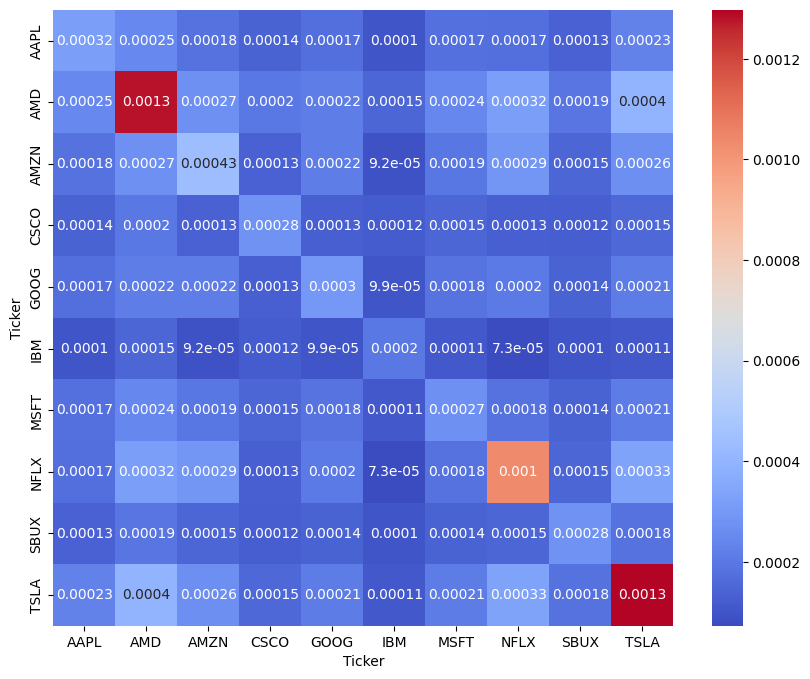

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(cov_mat, annot=True, cmap='coolwarm')
plt.show()

The heatmap visualizes the covariance matrix of stock returns. The diagonal values represent the volatility of each stock, while the off-diagonal values show how stocks move together. Most stocks have positive covariance, indicating that technology stocks tend to move in the same direction. AMD and Netflix show the highest volatility in the dataset.

---

# 1️⃣3️⃣ Eigenvalues and Eigenvectors

For covariance matrix:

$$
\Sigma v = \lambda v
$$

Where:

```
λ = eigenvalue
v = eigenvector
```

Interpretation:

* Eigenvectors → directions of variation
* Eigenvalues → strength of variation

---

### Compute Eigenvalues

In [ ]:
eigenvalues, eigenvectors = np.linalg.eig(cov_mat)

In [ ]:
eigenvalues

array([2.53980906e-03, 8.98827582e-04, 8.15484298e-04, 5.55636499e-04,
       2.34940021e-04, 1.66821287e-04, 1.53770214e-04, 9.38656683e-05,
       1.25646738e-04, 1.11265937e-04])

In [ ]:
eigenvectors

array([[ 0.22628884,  0.03317672, -0.0086836 ,  0.32050981,  0.03620646,
         0.66948955,  0.42862677,  0.08950002,  0.44429513,  0.07895712],
       [ 0.51993922,  0.66138773,  0.39366989, -0.36815923, -0.02191096,
        -0.02036386,  0.00560297,  0.02118841, -0.01681486, -0.00737707],
       [ 0.27880539,  0.01785398, -0.1534137 ,  0.29791728, -0.73572822,
        -0.25593875, -0.28123042, -0.00409216,  0.34151675,  0.0843604 ],
       [ 0.17794671,  0.06291433, -0.0119472 ,  0.32619503,  0.45983761,
         0.01902318, -0.58168792,  0.20651509,  0.20637012, -0.47161465],
       [ 0.22343006,  0.02545698, -0.08825891,  0.33724369, -0.17938677,
         0.10229868,  0.11820022,  0.51794546, -0.70524672, -0.07517738],
       [ 0.12719918,  0.05343899,  0.01592262,  0.25972771,  0.34593623,
        -0.09128615, -0.24629922,  0.00946168, -0.06162536,  0.8489388 ],
       [ 0.22316824,  0.04850799, -0.03937517,  0.32259197,  0.01283796,
         0.14000817, -0.02558429, -0.82489146

The PCA results suggest that one main factor drives a large part of the movement in these stocks. Most stocks load positively on the first component, which means they tend to move together. AMD, Tesla, and Netflix have the strongest loadings, so they are more affected by this common factor.

# 1️⃣4️⃣ PCA for Factor Analysis

Financial markets often move due to a few common factors.

Examples:

* Market factor
* Sector factor
* Macro factor

PCA extracts these factors.

---

### Standardize Data

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(returns)

NameError: name 'StandardScaler' is not defined

---

### Run PCA

In [ ]:
pca =PCA()
pca.fit(X_scaled)

PCA()


---

### Explained Variance

In [ ]:
explained_variance = pca.explained_variance_ratio_

print(explained_variance)

[0.46267385 0.1024287  0.07693634 0.06914797 0.0644774  0.05670843
 0.04936525 0.04622939 0.03870158 0.03333109]


The explained variance ratio shows how much of the total variation in stock returns is captured by each principal component. The first component explains the largest portion of the variance, suggesting that a common market factor drives much of the movement in these stocks.

Often:
```
First component explains ~30–50%
```

This represents **market factor**.

---

### Principal Components

In [ ]:
factor = pca.transform(X_scaled)
factor

array([[-2.65131905,  0.46637263,  0.2944128 , ..., -0.75552425,
         0.70478911,  0.38928909],
       [-0.54599246, -0.31064344, -1.46787133, ..., -0.51260102,
         0.49637708,  0.89808743],
       [-2.30585937, -1.60590335, -2.13151393, ...,  0.27351121,
        -0.37745096,  0.55297032],
       ...,
       [-0.54662549, -0.43243795,  0.35617152, ..., -0.33626141,
        -0.24505585,  0.13982683],
       [-2.63132226, -1.43987421, -0.41874362, ...,  0.35096456,
         0.57911977, -0.1965206 ],
       [ 0.86259953,  0.40127613,  0.52705237, ..., -0.61362434,
        -0.09605309, -0.29082548]])

The PCA-transformed data shows the factor scores for each trading day. Each row represents one day, and each column represents a principal component. These scores show how strongly each day is influenced by the hidden factors extracted from the stock return data.

These are **latent market factors**.

---

# 1️⃣5️⃣ Visualizing PCA Variance

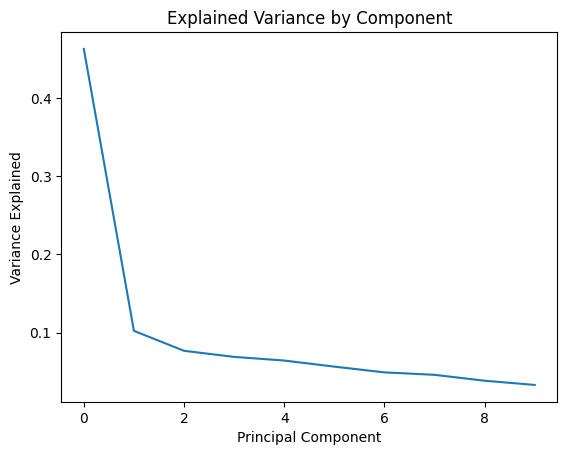

In [ ]:
plt.plot(explained_variance)
plt.title('Explained Variance by Component')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.show()

The scree plot shows that the first principal component explains the largest portion of variance in the stock returns. This suggests that a common market factor drives much of the movement across the stocks. The remaining components explain progressively smaller portions of variance, indicating that only a few factors are needed to capture most of the structure in the data.

Observation:

First few components explain most variance.

---

# 1️⃣6️⃣ Feature Stability Over Time

Financial relationships change.

We test stability by computing covariance in rolling windows.

---

### Rolling Covariance

In [ ]:
rolling_cov = returns.rolling(60).cov()

rolling_cov.head()

Ticker             AAPL  AMD  AMZN  CSCO  GOOG  IBM  MSFT  NFLX  SBUX  TSLA
Date       Ticker                                                          
2010-06-30 AAPL     NaN  NaN   NaN   NaN   NaN  NaN   NaN   NaN   NaN   NaN
           AMD      NaN  NaN   NaN   NaN   NaN  NaN   NaN   NaN   NaN   NaN
           AMZN     NaN  NaN   NaN   NaN   NaN  NaN   NaN   NaN   NaN   NaN
           CSCO     NaN  NaN   NaN   NaN   NaN  NaN   NaN   NaN   NaN   NaN
           GOOG     NaN  NaN   NaN   NaN   NaN  NaN   NaN   NaN   NaN   NaN

The rolling covariance matrix measures how the relationship between stock returns changes over time. A 60-day rolling window is used, meaning each covariance value is calculated using the previous 60 days of returns. The first rows contain NaN values because there are not enough observations to compute the rolling statistics.


---

### Rolling Correlation

In [ ]:
rolling_corr = returns.rolling(60).corr()

rolling_corr.head()

NameError: name 'returns' is not defined

If correlation changes drastically:

Feature instability exists.

---

# 1️⃣7️⃣ Removing Noisy Features

Noisy features:

* Low variance
* Unstable correlations
* Weak contribution to PCA

---

### Variance Filtering

In [ ]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)
X_filtered = selector.fit_transform(X)

ANy text here

---

### PCA Noise Reduction

Keep first components.

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)
X_reduced = pca.fit_transform(X_scaled)






This removes noise.

---

# 📊 Final Insights

1. Stock returns behave like **random variables**
2. Returns distributions show **heavy tails**
3. Markets exhibit **high kurtosis and skewness**
4. Classical statistical assumptions often fail
5. Financial data naturally forms **vector and matrix structures**
6. Covariance matrices describe asset relationships
7. PCA extracts **latent market factors**
8. Feature stability must be monitored over time
9. Noisy features can degrade models
10. PCA helps **denoise financial data**

---



